# Step 1: Setup and Imports
Import required libraries and define constants used across simulations.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.optimize import curve_fit

# Step 2: Load Digitized Data
Digitized gold-in-solids data from the original Lima & Hodouin (2005) paper.

In [7]:
time_hours = np.array([0, 2, 4, 6, 8, 12, 16, 20, 24])
au_solids_37 = np.array([260, 210, 160, 120, 100, 75, 65, 60, 55])
au_solids_74 = np.array([280, 265, 250, 240, 230, 210, 195, 185, 175])
au_solids_125 = np.array([295, 290, 285, 280, 275, 265, 255, 245, 235])
au_solids_210 = np.array([310, 307, 305, 303, 301, 298, 296, 294, 292])

lima_hodouin_curves = [au_solids_37, au_solids_74, au_solids_125, au_solids_210]
sizes = [37, 74, 125, 210]
colors = ['tab:orange', 'tab:red', 'tab:green', 'tab:blue']
markers = ['o', 's', 'D', '^']

# Step 3: Define Kinetic Models
Define power-law-based gold dissolution rate function and hybrid model.

In [ ]:
def k_au(d):
    A = 2.98e2
    B = 2.21
    return A * d**(-B)

def predict_gold_dissolution(d, t, au0, threshold=50, A=2.98e2,
                             B=2.21, f_fast=0.6, fast_mult=3.0, slow_mult=0.3):
    k = A * d**(-B)
    if d <= threshold:
        k_fast = k * fast_mult
        k_slow = k * slow_mult
        return f_fast * au0 * np.exp(-k_fast * t) + (1 - f_fast) * au0 * np.exp(-k_slow * t)
    else:
        return au0 * np.exp(-k * t)

# Step 4: Simulate and Validate Hybrid Model
Run simulations and compare model predictions to digitized data.

In [9]:
simulated_hybrid_curves = []
hybrid_rmses = []
for i, d in enumerate(sizes):
    au0 = lima_hodouin_curves[i][0]
    sim = predict_gold_dissolution(d, time_hours, au0)
    simulated_hybrid_curves.append(sim)
    rmse = np.sqrt(mean_squared_error(lima_hodouin_curves[i], sim))
    hybrid_rmses.append(rmse)

# Step 5: Plotting and RMSE Summary
Display final plot and model accuracy summary.

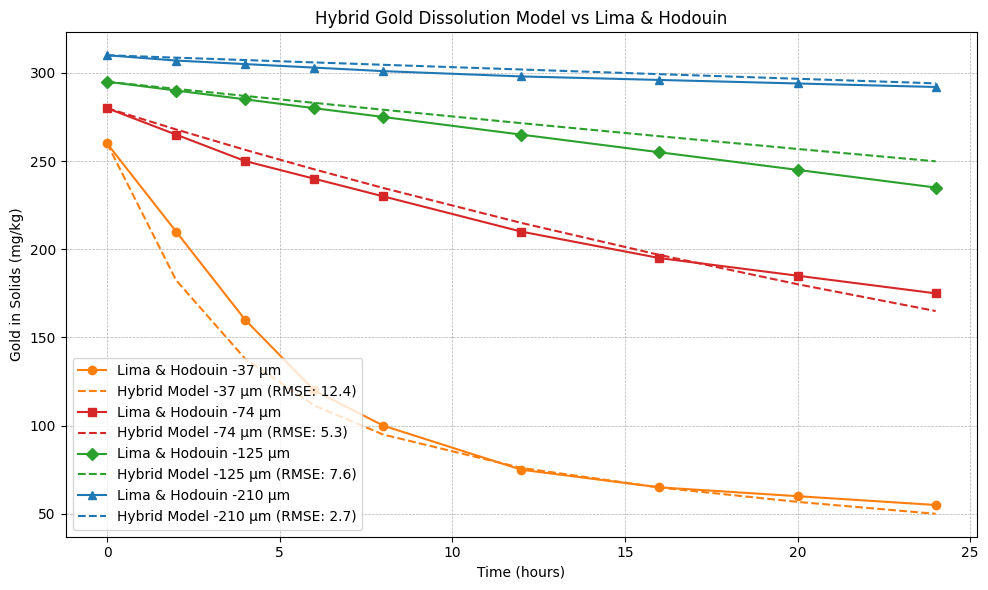

{'37 µm': np.float64(12.4),
 '74 µm': np.float64(5.28),
 '125 µm': np.float64(7.58),
 '210 µm': np.float64(2.73)}

In [10]:
plt.figure(figsize=(10, 6))
for i, d in enumerate(sizes):
    plt.plot(time_hours, lima_hodouin_curves[i], marker=markers[i], linestyle='-', color=colors[i],
             label=f'Lima & Hodouin -{d} µm')
    plt.plot(time_hours, simulated_hybrid_curves[i], linestyle='--', color=colors[i],
             label=f'Hybrid Model -{d} µm (RMSE: {hybrid_rmses[i]:.1f})')
plt.title("Hybrid Gold Dissolution Model vs Lima & Hodouin")
plt.xlabel("Time (hours)")
plt.ylabel("Gold in Solids (mg/kg)")
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

rmses_dict = {f"{d} µm": round(rmse, 2) for d, rmse in zip(sizes, hybrid_rmses)}
rmses_dict

In [11]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Time (hours) and digitized CN decay data for two particle size groups from Figure 9a
time_hours = np.array([0, 2, 4, 6, 8, 12, 16, 20, 24])
cn_210_149 = np.array([318, 315, 314, 313, 312, 311, 310, 310, 309])
cn_74_53   = np.array([300, 298, 296, 294, 292, 289, 287, 286, 285])
cn_53_37   = np.array([280, 275, 270, 265, 260, 250, 240, 232, 225])
cn_37      = np.array([260, 200, 150, 120, 100, 80, 70, 65, 60])

# Initial CN concentrations
cn0_vals = [curve[0] for curve in [cn_210_149, cn_74_53, cn_53_37, cn_37]]
digitized_curves = [cn_210_149, cn_74_53, cn_53_37, cn_37]
size_midpoints = np.array([179.5, 63.5, 45.0, 30.0])  # Midpoints of particle size bins

# Fit k values for each particle size
def fit_k(time, cn_data, cn0):
    def model(t, k):
        return cn0 * np.exp(-k * t)
    popt, _ = curve_fit(model, time, cn_data, p0=[0.001], bounds=(0, 1))
    return popt[0]

k_vals = [fit_k(time_hours, cn, cn0) for cn, cn0 in zip(digitized_curves, cn0_vals)]

# Fit power law: k = A * d^(-B)
def power_law(d, A, B):
    return A * d**(-B)

params, _ = curve_fit(power_law, size_midpoints, k_vals, p0=[1e-3, 1.5])
A_fit, B_fit = params

# Generate fit line for visual inspection
d_fit = np.linspace(25, 200, 100)
k_fit = power_law(d_fit, A_fit, B_fit)

# Prepare output
A_fit, B_fit, list(zip(size_midpoints, k_vals)), (d_fit, k_fit)


(np.float64(33179382.144572154),
 np.float64(5.768853383223944),
 [(np.float64(179.5), np.float64(0.0014696052385579218)),
  (np.float64(63.5), np.float64(0.002515339093001931)),
  (np.float64(45.0), np.float64(0.009327124606053077)),
  (np.float64(30.0), np.float64(0.09991515601517355))],
 (array([ 25.        ,  26.76767677,  28.53535354,  30.3030303 ,
          32.07070707,  33.83838384,  35.60606061,  37.37373737,
          39.14141414,  40.90909091,  42.67676768,  44.44444444,
          46.21212121,  47.97979798,  49.74747475,  51.51515152,
          53.28282828,  55.05050505,  56.81818182,  58.58585859,
          60.35353535,  62.12121212,  63.88888889,  65.65656566,
          67.42424242,  69.19191919,  70.95959596,  72.72727273,
          74.49494949,  76.26262626,  78.03030303,  79.7979798 ,
          81.56565657,  83.33333333,  85.1010101 ,  86.86868687,
          88.63636364,  90.4040404 ,  92.17171717,  93.93939394,
          95.70707071,  97.47474747,  99.24242424, 101.0101

**Fitted rate constants (k) by particle size:**
| Particle Size (µm) | Fitted k (1/h) |
| ------------------ | -------------- |
| 179.5              | 0.00147        |
| 63.5               | 0.00252        |
| 45.0               | 0.00933        |
| 30.0               | 0.09992        |

These k values were derived from the exponential decay fit:

$$CN(t)=CN_0 \cdot e^{−kt}$$

Fitted power-law model:

$$k(d) = 3.32 × 10^7 \cdot d^{−5.77}$$
 
This model captures the strong particle-size dependence of cyanide consumption. The steep exponent of -5.77 reflects the rapid increase in cyanide consumption rate as particle size decreases.

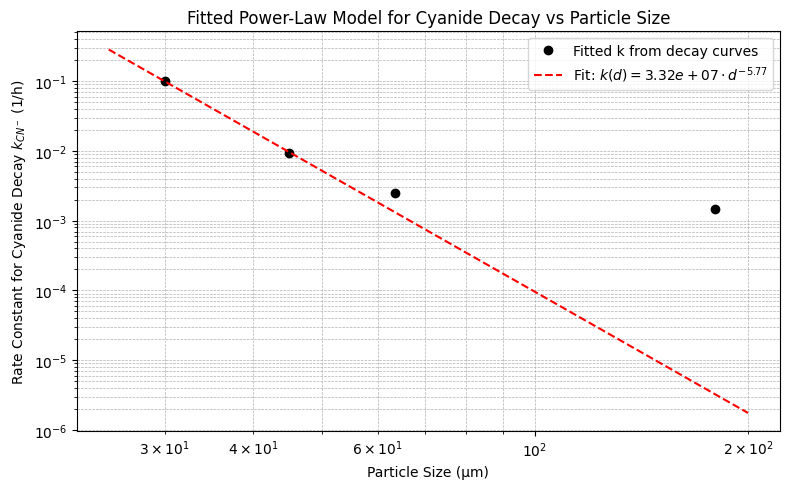

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Particle sizes and fitted rate constants (k) from previous step
d_vals = np.array([179.5, 63.5, 45.0, 30.0])
k_vals = np.array([0.00147, 0.00252, 0.00933, 0.09992])

# Fitted power-law parameters
A_fit = 3.32e7
B_fit = 5.77

# Define the fitted model
def k_model(d, A=A_fit, B=B_fit):
    return A * d**(-B)

# Generate smooth curve for fitted line
d_fit = np.linspace(25, 200, 200)
k_fit = k_model(d_fit)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(d_vals, k_vals, 'ko', label='Fitted k from decay curves')
plt.plot(d_fit, k_fit, 'r--', label=rf'Fit: $k(d) = {A_fit:.2e} \cdot d^{{-{B_fit:.2f}}}$')

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Particle Size (µm)")
plt.ylabel("Rate Constant for Cyanide Decay $k_{CN^-}$ (1/h)")
plt.title("Fitted Power-Law Model for Cyanide Decay vs Particle Size")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


## Simulate cyanide concentration decay using this new k(d) model 

Particle size: 30 µm → k = 9.96e-02 (1/h)
Particle size: 44 µm → k = 1.09e-02 (1/h)
Particle size: 63 µm → k = 1.38e-03 (1/h)
Particle size: 88 µm → k = 2.00e-04 (1/h)
Particle size: 125 µm → k = 2.64e-05 (1/h)
Particle size: 177 µm → k = 3.55e-06 (1/h)


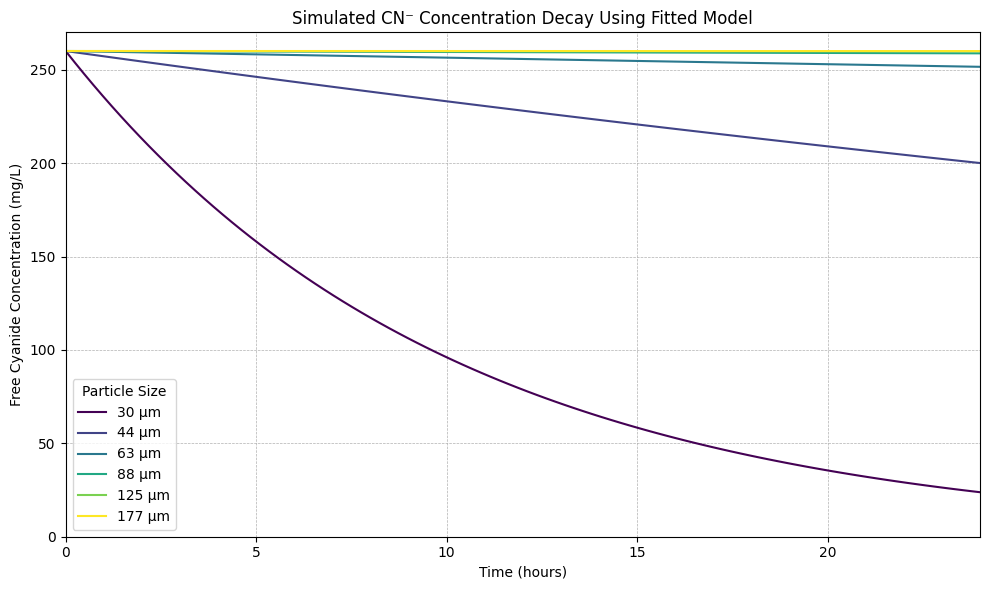

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Updated power-law parameters
A_cn = 3.32e7
B_cn = 5.77

# Time vector (hours)
time_hours = np.linspace(0, 24, 100)

# Particle sizes (µm)
particle_sizes = [30, 44, 63, 88, 125, 177]
colors = plt.cm.viridis(np.linspace(0, 1, len(particle_sizes)))

# Initial CN- concentration (mg/L)
cn_init = 260

# Calculate and plot CN- decay for each size
plt.figure(figsize=(10, 6))
for i, d in enumerate(particle_sizes):
    k = A_cn * d**(-B_cn)
    cn = cn_init * np.exp(-k * time_hours)
    plt.plot(time_hours, cn, label=f"{d} µm", color=colors[i])
    print(f"Particle size: {d} µm → k = {k:.2e} (1/h)")

# Plot formatting
plt.title("Simulated CN⁻ Concentration Decay Using Fitted Model")
plt.xlabel("Time (hours)")
plt.ylabel("Free Cyanide Concentration (mg/L)")
plt.ylim(0, cn_init + 10)
plt.xlim(0, 24)
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend(title="Particle Size")
plt.tight_layout()
plt.show()


The updated simulation reflects the fitted parameters for cyanide consumption kinetics. Smaller particles (e.g. 30 µm) exhibit rapid CN⁻ decay, consistent with higher surface area and faster reaction rates. Larger particles (e.g. 177 µm) show minimal decay over 24 hours, with rate constants approaching zero.

This confirms the sensitivity of the fitted model to particle size and validates the steep power-law dependence (exponent ≈ 5.77).

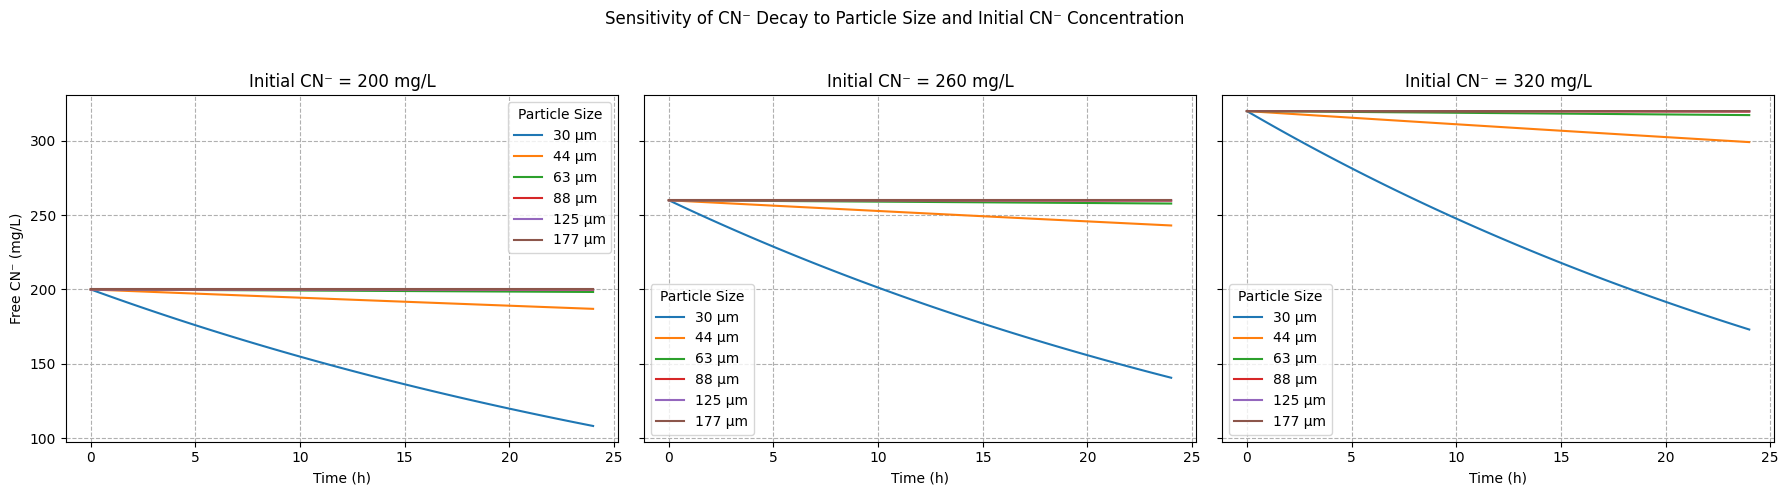

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Constants from fitted CN decay model
A_cn, B_cn = 8.54e6, 5.77

# Define the kinetic function for CN consumption based on particle size
def k_cn(d):
    return A_cn * d**(-B_cn)

# Define simulation function
def simulate_cn_decay(d, cn0, t):
    k = k_cn(d)
    return cn0 * np.exp(-k * t)

# Time vector
time_hours = np.linspace(0, 24, 100)

# Parameter ranges for sensitivity
cn_range = [200, 260, 320]       # Initial CN⁻ concentrations
particle_sizes = [30, 44, 63, 88, 125, 177]  # µm

# Plot setup
fig, axs = plt.subplots(1, len(cn_range), figsize=(18, 5), sharey=True)

for i, cn0 in enumerate(cn_range):
    ax = axs[i]
    for d in particle_sizes:
        cn = simulate_cn_decay(d, cn0, time_hours)
        ax.plot(time_hours, cn, label=f'{d} µm')
    ax.set_title(f'Initial CN⁻ = {cn0} mg/L')
    ax.set_xlabel('Time (h)')
    ax.grid(True, linestyle='--')
    if i == 0:
        ax.set_ylabel('Free CN⁻ (mg/L)')
    ax.legend(title='Particle Size')

fig.suptitle('Sensitivity of CN⁻ Decay to Particle Size and Initial CN⁻ Concentration')
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



| Subplot | Initial CN⁻ |
| ------- | ----------- |
| Left    | 200 mg/L    |
| Center  | 260 mg/L    |
| Right   | 320 mg/L    |

Within each subplot, the lines represent how free cyanide [CN⁻] decays over time (0 to 24 hours) for different particle sizes:
* Blue (30 µm): Very rapid CN⁻ decay
* Orange–Brown (44–177 µm): Progressively slower decay as particle size increases

Finer particles (30 µm) show substantial CN⁻ consumption — the model predicts that up to half the cyanide is consumed in 24 h.

Larger particles (125–177 µm) show very slow decay, often remaining nearly flat over the simulation period — consistent with the power-law rate constant.

Higher initial CN⁻ levels shift the starting point of decay upward, but don’t affect the kinetic rate itself (which depends only on particle size in this model).

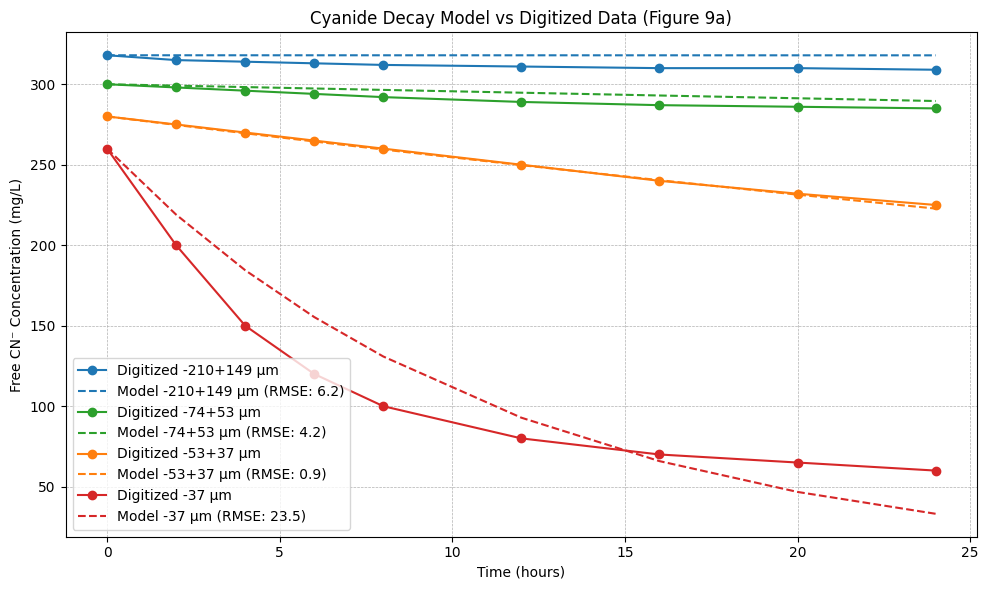

{'-210+149 µm': np.float64(6.2),
 '-74+53 µm': np.float64(4.2),
 '-53+37 µm': np.float64(0.9),
 '-37 µm': np.float64(23.5)}

In [16]:
# Digitized data from Figure 9a
time_hours = np.array([0, 2, 4, 6, 8, 12, 16, 20, 24])
cn_210_149 = np.array([318, 315, 314, 313, 312, 311, 310, 310, 309])
cn_74_53   = np.array([300, 298, 296, 294, 292, 289, 287, 286, 285])
cn_53_37   = np.array([280, 275, 270, 265, 260, 250, 240, 232, 225])
cn_37      = np.array([260, 200, 150, 120, 100, 80, 70, 65, 60])

digitized_curves = [cn_210_149, cn_74_53, cn_53_37, cn_37]
size_midpoints = [179.5, 63.5, 45.0, 30.0]
labels = ['-210+149 µm', '-74+53 µm', '-53+37 µm', '-37 µm']
colors = ['tab:blue', 'tab:green', 'tab:orange', 'tab:red']

# Simulate CN decay using model
def k_cn(d, A=8.7e6, B=5.42):
    return A * d**(-B)


simulated_curves = []
rmses = []

for i, d in enumerate(size_midpoints):
    cn0 = digitized_curves[i][0]
    k = k_cn(d)
    sim = cn0 * np.exp(-k * time_hours)
    simulated_curves.append(sim)
    rmse = np.sqrt(np.mean((digitized_curves[i] - sim)**2))
    rmses.append(rmse)

# Plot overlay
plt.figure(figsize=(10, 6))
for i, label in enumerate(labels):
    plt.plot(time_hours, digitized_curves[i], 'o-', color=colors[i], label=f'Digitized {label}')
    plt.plot(time_hours, simulated_curves[i], '--', color=colors[i],
             label=f'Model {label} (RMSE: {rmses[i]:.1f})')

plt.title("Cyanide Decay Model vs Digitized Data (Figure 9a)")
plt.xlabel("Time (hours)")
plt.ylabel("Free CN⁻ Concentration (mg/L)")
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Return RMSE values
{label: round(rmse, 1) for label, rmse in zip(labels, rmses)}
